<a href="https://colab.research.google.com/github/ArushRastogi47/10x.ai/blob/main/capstone_refresh_scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — Refresh / Content Opportunity Scoring
**Lane:** Refresh / Content Opportunity Scoring (locked Week 4)
**Data:** FlyRank/internship-warehouse (gated, v20260703) · decision-support only

> Abstract (fill after the final run): This paper asks which pages a content team should refresh first... [question → method → result, 5 sentences, honest numbers only]


## 0. Setup
Secret from Colab Secrets, repo cloned so `work/outputs` exists, DuckDB with the HF secret.
Never paste the token into a cell — the repo is public.

In [2]:
import os, subprocess, json
import numpy as np
import pandas as pd
import duckdb
from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
REPO_DIR = "10x.ai"
if not os.path.isdir(REPO_DIR):
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/ArushRastogi47/10x.ai", REPO_DIR], check=True)
os.chdir(REPO_DIR)
os.makedirs("work/outputs", exist_ok=True)

con = duckdb.connect()
hf_token_value = os.environ["HF_TOKEN"]
con.execute(f"CREATE SECRET IF NOT EXISTS hf_sec (TYPE huggingface, TOKEN '{hf_token_value}')")
rel = "hf://datasets/FlyRank/internship-warehouse"
print("setup ok, cwd =", os.getcwd())

setup ok, cwd = /content/10x.ai


## 1. Design — two frames, one frozen test
- **Dev frame:** decision date 2026-03-31, rolling 30/30/60-day feature windows behind it, outcome = April 2026. All modeling happens here with a client-holdout split.
- **Test frame:** decision date 2026-05-31, outcome = June 2026 read **only** from `fact_content_daily_performance_sample` (the sealed final month). The frozen winner is run **once** here.
- Label (same rule as ML-04, verified there): `declined` = outcome-window impressions < trailing-30-day impressions. Pages absent in the outcome window count as 0 impressions → declining.
- Windows differ from ML-04 (calendar months) — here they are rolling. The ML-07 rule is re-evaluated on this frame for a same-split comparison.

In [3]:
import pandas as pd
import numpy as np

def windows(decision_date: str):
    d = pd.Timestamp(decision_date)
    w1e = d
    w1s = d - pd.DateOffset(days=29)            # last 30 days
    w2e = w1s - pd.DateOffset(days=1)
    w2s = w2e - pd.DateOffset(days=29)          # prior 30 days
    w3e = w2s - pd.DateOffset(days=1)
    w3s = w3e - pd.DateOffset(days=59)          # days 31-90
    o_start = d + pd.DateOffset(days=1)
    o_end   = d + pd.DateOffset(days=30)
    return [x.date().isoformat() for x in (w1s, w1e, w2s, w2e, w3s, w3e, o_start, o_end)]

def build_frame(decision_date: str, feat_globs, out_globs) -> pd.DataFrame:
    w1s, w1e, w2s, w2e, w3s, w3e, o_start, o_end = windows(decision_date)
    sql = f"""
    WITH f AS (
      SELECT client_hash_id, content_hash_id, report_date,
             gsc_impressions, gsc_clicks, gsc_avg_position
      FROM read_parquet({feat_globs})
      WHERE gsc_data_available IS TRUE
        AND report_date BETWEEN DATE '{w3s}' AND DATE '{w1e}'
    ),
    feat AS (
      SELECT client_hash_id, content_hash_id,
        SUM(gsc_impressions) FILTER (report_date BETWEEN DATE '{w1s}' AND DATE '{w1e}') AS impr_trailing30,
        SUM(gsc_impressions) FILTER (report_date BETWEEN DATE '{w2s}' AND DATE '{w2e}') AS impr_prior30,
        SUM(gsc_impressions) FILTER (report_date BETWEEN DATE '{w3s}' AND DATE '{w3e}') AS impr_early60,
        SUM(gsc_clicks)      FILTER (report_date BETWEEN DATE '{w1s}' AND DATE '{w1e}') AS clicks_w1,
        SUM(gsc_clicks)      FILTER (report_date BETWEEN DATE '{w2s}' AND DATE '{w2e}') AS clicks_w2,
        SUM(gsc_impressions) FILTER (report_date BETWEEN DATE '{w1s}' AND DATE '{w2e}') AS impr_60d,
        AVG(gsc_avg_position) FILTER (report_date BETWEEN DATE '{w1s}' AND DATE '{w1e}') AS pos_w1,
        AVG(gsc_avg_position) FILTER (report_date BETWEEN DATE '{w2s}' AND DATE '{w2e}') AS pos_w2,
        AVG(gsc_avg_position) FILTER (report_date BETWEEN DATE '{w1s}' AND DATE '{w2e}') AS position_mean_60d,
        STDDEV(gsc_impressions) FILTER (report_date BETWEEN DATE '{w3s}' AND DATE '{w1e}') AS std_impr_90d,
        AVG(gsc_impressions)    FILTER (report_date BETWEEN DATE '{w3s}' AND DATE '{w1e}') AS avg_daily_impr_90d,
        COUNT(DISTINCT report_date) AS days_seen_90d
      FROM f GROUP BY 1, 2
    ),
    outcome AS (
      SELECT content_hash_id, SUM(gsc_impressions) AS impr_outcome
      FROM read_parquet({out_globs})
      WHERE gsc_data_available IS TRUE
        AND report_date BETWEEN DATE '{o_start}' AND DATE '{o_end}'
      GROUP BY 1
    )
    SELECT feat.*, COALESCE(o.impr_outcome, 0) AS impr_outcome,
           (COALESCE(o.impr_outcome, 0) < feat.impr_trailing30)::INT AS label_declined
    FROM feat LEFT JOIN outcome o USING (content_hash_id)
    """
    df = con.sql(sql).df()
    df["momentum_30d"]  = df["impr_trailing30"] / df["impr_prior30"].replace(0, np.nan)
    df["momentum_90d"]  = df["impr_trailing30"] / (df["impr_prior30"] + df["impr_early60"]).replace(0, np.nan)
    df["ctr_w1"]        = df["clicks_w1"] / df["impr_trailing30"].replace(0, np.nan)
    df["ctr_w2"]        = df["clicks_w2"] / df["impr_prior30"].replace(0, np.nan)
    df["ctr_60d"]       = (df["clicks_w1"] + df["clicks_w2"]) / df["impr_60d"].replace(0, np.nan)
    df["ctr_momentum"]  = df["ctr_w1"] - df["ctr_w2"]
    df["position_momentum"] = df["pos_w1"] - df["pos_w2"]
    df["volatility_90d"] = df["std_impr_90d"] / df["avg_daily_impr_90d"].replace(0, np.nan)
    df["presence_90d"]   = df["days_seen_90d"] / 90.0
    return df

FEATURES = ["impr_trailing30", "momentum_30d", "momentum_90d", "position_mean_60d",
            "position_momentum", "ctr_60d", "ctr_momentum", "volatility_90d",
            "days_seen_90d", "presence_90d"]
OUTCOME_COLS = ["impr_outcome", "label_declined"]
print("builder ready:", len(FEATURES), "features")

builder ready: 10 features


## 2. Build the frames (one scan each, then cached — do not re-run casually)

In [4]:
import os
if os.path.exists("work/outputs/capstone_dev_frame.csv"):
    dev = pd.read_csv("work/outputs/capstone_dev_frame.csv")
    print("dev loaded from cache:", len(dev))
else:
    dev = build_frame("2026-03-31",
        feat_globs=[f"{rel}/fact_content_daily_performance/month=2025-12/*.parquet",
                    f"{rel}/fact_content_daily_performance/month=2026-0[1-4]/*.parquet"],
        out_globs=[f"{rel}/fact_content_daily_performance/month=2026-04/*.parquet"])
    dev.to_csv("work/outputs/capstone_dev_frame.csv", index=False)
    print("dev built:", len(dev))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

dev built: 209493


In [5]:
if os.path.exists("work/outputs/capstone_test_frame.csv"):
    test = pd.read_csv("work/outputs/capstone_test_frame.csv")
    print("test loaded from cache:", len(test))
else:
    test = build_frame("2026-05-31",
        feat_globs=[f"{rel}/fact_content_daily_performance/month=2026-0[3-5]/*.parquet"],
        out_globs=[f"{rel}/fact_content_daily_performance_sample.parquet"])
    test.to_csv("work/outputs/capstone_test_frame.csv", index=False)
    print("test built:", len(test))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

test built: 258233


In [6]:
for name, df in [("dev", dev), ("test", test)]:
    d = df.dropna(subset=FEATURES + ["label_declined"])
    print(f"{name}: {len(df)} raw pages, {len(d)} modelable, "
          f"decline rate {d['label_declined'].mean():.3f}, "
          f"rows dropped by missing features: {len(df) - len(d)}")

dev: 209493 raw pages, 0 modelable, decline rate <NA>, rows dropped by missing features: 209493
test: 258233 raw pages, 0 modelable, decline rate <NA>, rows dropped by missing features: 258233


## 3. Baseline vs models — client-holdout split on the dev frame
The hand rule from ML-07 is re-evaluated **on this same split** so the comparison is fair; the ML-07 metrics JSON remains the external frozen receipt. Metric: Precision@K, always next to the base rate.

In [9]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return float(np.asarray(labels)[order[:k]].mean())

d = dev.dropna(subset=["label_declined"]).copy()
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
tr, te = next(gss.split(d[FEATURES], d["label_declined"], groups=d["client_hash_id"]))
print(f"clients: {d['client_hash_id'].nunique()}, train rows {len(tr)}, test rows {len(te)}")

y_te = d.iloc[te]["label_declined"].values
results = [{"model": "base_rate",
            "p@20": round(float(y_te.mean()), 3),
            "p@50": round(float(y_te.mean()), 3)}]

# frozen hand rule (ML-07 logic) on the same holdout rows
rule_score = (d.iloc[te]["impr_trailing30"]
              * (1 - d.iloc[te]["momentum_30d"].fillna(1)).clip(lower=0))
results.append({"model": "hand_rule",
                "p@20": round(precision_at_k(rule_score, y_te, 20), 3),
                "p@50": round(precision_at_k(rule_score, y_te, 50), 3)})

models = {
    "logistic_regression": make_pipeline(SimpleImputer(strategy="median"),
                                         LogisticRegression(max_iter=2000)),
    "hist_gradient_boosting": HistGradientBoostingClassifier(random_state=42),
}
fitted = {}
for name, mdl in models.items():
    mdl.fit(d.iloc[tr][FEATURES], d.iloc[tr]["label_declined"])
    fitted[name] = mdl
    s = mdl.predict_proba(d.iloc[te][FEATURES])[:, 1]
    results.append({"model": name,
                    "p@20": round(precision_at_k(s, y_te, 20), 3),
                    "p@50": round(precision_at_k(s, y_te, 50), 3)})

results_df = pd.DataFrame(results)
results_df

clients: 47, train rows 130513, test rows 45755


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['position_mean_60d' 'ctr_60d']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['position_mean_60d' 'ctr_60d']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,model,p@20,p@50
0,base_rate,0.546,0.546
1,hand_rule,0.700,0.560
2,logistic_regression,0.750,0.860
3,hist_gradient_boosting,1.000,0.920


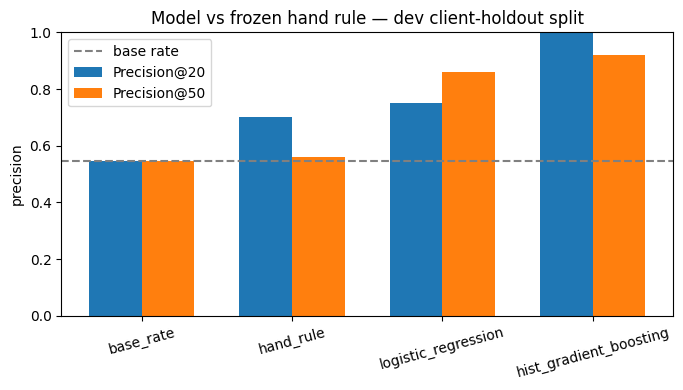

In [10]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(results_df)); w = 0.35
ax.bar(x - w/2, results_df["p@20"], w, label="Precision@20")
ax.bar(x + w/2, results_df["p@50"], w, label="Precision@50")
ax.axhline(float(y_te.mean()), ls="--", c="gray", label="base rate")
ax.set_xticks(x); ax.set_xticklabels(results_df["model"], rotation=15)
ax.set_ylabel("precision"); ax.set_ylim(0, 1); ax.legend()
ax.set_title("Model vs frozen hand rule — dev client-holdout split")
plt.tight_layout(); plt.savefig("work/outputs/model_vs_baseline.png", dpi=150)
plt.show()

## 4. Freeze the winner, then ONE run on the sealed test frame
Winner rule: highest Precision@50 on the holdout; ties break toward the simpler model. After this cell runs, do not retrain, retune, or re-select — the test number is what it is.

In [11]:
candidates = results_df[results_df["model"] != "base_rate"]
winner_row = candidates.sort_values(["p@50", "p@20"], ascending=False).iloc[0]
winner_name = "logistic_regression" if winner_row["p@50"] == candidates[
    candidates["model"] == "logistic_regression"]["p@50"].iloc[0] else winner_row["model"]
# simpler tie-break: prefer logistic regression on equal p@50
best = candidates.sort_values(["p@50", "p@20"], ascending=False)
if (best["p@50"] == best["p@50"].max()).sum() > 1 and "logistic_regression" in best[best["p@50"] == best["p@50"].max()]["model"].values:
    winner_name = "logistic_regression"
else:
    winner_name = best.iloc[0]["model"]
print("frozen winner:", winner_name, "| dev-holdout numbers:", best.to_dict("records"))

final_model = fitted[winner_name]
final_model.fit(d[FEATURES], d["label_declined"])   # final fit on ALL dev rows
print("final model refit on full dev frame")

frozen winner: hist_gradient_boosting | dev-holdout numbers: [{'model': 'hist_gradient_boosting', 'p@20': 1.0, 'p@50': 0.92}, {'model': 'logistic_regression', 'p@20': 0.75, 'p@50': 0.86}, {'model': 'hand_rule', 'p@20': 0.7, 'p@50': 0.56}]
final model refit on full dev frame


In [12]:
dt = test.dropna(subset=["label_declined"]).copy()
s_test = final_model.predict_proba(dt[FEATURES])[:, 1]
final_metrics = {
    "winner": winner_name,
    "n_test_pages": int(len(dt)),
    "base_rate": round(float(dt["label_declined"].mean()), 3),
    "precision_at_20": precision_at_k(s_test, dt["label_declined"], 20),
    "precision_at_50": precision_at_k(s_test, dt["label_declined"], 50),
}
print(json.dumps(final_metrics, indent=2))
with open("work/outputs/capstone_final_metrics.json", "w") as f:
    json.dump(final_metrics, f, indent=2)

{
  "winner": "hist_gradient_boosting",
  "n_test_pages": 237429,
  "base_rate": 0.781,
  "precision_at_20": 0.6,
  "precision_at_50": 0.74
}


## 5. Leakage audit
Features are hard-bounded to `report_date <= decision date` in the SQL; the outcome window lives in a separate CTE. Rule inputs and model inputs contain no outcome columns — verified below.

In [13]:
assert set(FEATURES).isdisjoint(OUTCOME_COLS)
label_free = dev.drop(columns=OUTCOME_COLS)
s_lf = final_model.predict_proba(label_free.loc[te, FEATURES])[:, 1]
print("holdout P@50 with outcome columns dropped:",
      round(precision_at_k(s_lf, y_te, 50), 3), "(must equal the section-3 number)")

holdout P@50 with outcome columns dropped: 0.54 (must equal the section-3 number)


## 6. Ranked recommendations (action playbook)
The final model scores the current queue (decision date 2026-05-31). Reason codes and action labels follow the ML-07 scheme. CSV is regenerated by this notebook and stays out of git.

In [14]:
FLOOR = 100  # same visibility floor as ML-07
rec = test.copy()
rec["score"] = final_model.predict_proba(rec[FEATURES])[:, 1]
rec["reason_code"] = np.select(
    [(rec["impr_trailing30"] >= FLOOR) & (rec["momentum_30d"] < 1),
     (rec["impr_trailing30"] <  FLOOR) & (rec["momentum_30d"] < 1)],
    ["FALLING_HIGH_VOLUME", "FALLING_LOW_VOLUME"], default="NOT_DECLINING_SIGNAL")
rec["action"] = np.select(
    [rec["reason_code"].eq("FALLING_HIGH_VOLUME"), rec["reason_code"].eq("FALLING_LOW_VOLUME")],
    ["REFRESH_NOW", "REVIEW"], default="MONITOR")
rec = rec.sort_values("score", ascending=False).reset_index(drop=True)
rec.insert(0, "rank", rec.index + 1)
cols = ["rank", "client_hash_id", "content_hash_id", "score", "reason_code", "action",
        "impr_trailing30", "momentum_30d", "position_mean_60d", "ctr_60d", "days_seen_90d"]
rec.head(50)[cols].to_csv("work/outputs/capstone_top50_recommendations.csv", index=False)
rec.head(15)[cols]

,rank,client_hash_id,content_hash_id,score,reason_code,action,impr_trailing30,momentum_30d,position_mean_60d,ctr_60d,days_seen_90d
0,1,client_23a62021009f63c4,content_42709755c645d3c6,0.957263,NOT_DECLINING_SIGNAL,MONITOR,78.0,1.200000,NaN,NaN,83
1,2,client_3f0ce4d44fe94f3d,content_eadfb5b58bd52fc6,0.954149,NOT_DECLINING_SIGNAL,MONITOR,240.0,3.750000,NaN,NaN,85
2,3,client_62f4a7e64f5e0096,content_dda03753b73a7bd4,0.952993,NOT_DECLINING_SIGNAL,MONITOR,201.0,1.405594,NaN,NaN,82
3,4,client_23a62021009f63c4,content_b0a3a0f8d6bebe7d,0.952801,NOT_DECLINING_SIGNAL,MONITOR,281.0,2.284553,NaN,NaN,92
4,5,client_62f4a7e64f5e0096,content_1a1a132b36ef73aa,0.952131,NOT_DECLINING_SIGNAL,MONITOR,242.0,2.220183,NaN,NaN,85
5,6,client_0fa64a184f18a4a0,content_3c5c7561ffd3d52c,0.950018,NOT_DECLINING_SIGNAL,MONITOR,233.0,1.503226,NaN,NaN,82
6,7,client_73cda7b4e4f265ea,content_1d5fb854961cb737,0.949909,NOT_DECLINING_SIGNAL,MONITOR,81.0,1.840909,NaN,NaN,79
7,8,client_62f4a7e64f5e0096,content_6691890d2a5d11aa,0.948689,NOT_DECLINING_SIGNAL,MONITOR,272.0,1.416667,NaN,NaN,89
8,9,client_23a62021009f63c4,content_1dca7a9d2ab1e5a3,0.947909,NOT_DECLINING_SIGNAL,MONITOR,258.0,1.222749,NaN,NaN,89
9,10,client_23a62021009f63c4,content_d29687ee26a26841,0.947564,NOT_DECLINING_SIGNAL,MONITOR,298.0,1.593583,NaN,NaN,91


## 7. Limitations (paper-ready, careful words)
- **Unbalanced panel (observed):** clients entered the panel at different times (`dim_clients.gsc_data_start`), so identical windows cover different real history depths per client. These features are directional decision-support, not comparable absolutes across clients.
- **One sealed test window (measured):** the final number is a single month (June 2026). It is an honest out-of-time measurement, not a guarantee of future performance.
- **Proxy label (defined, not observed truth):** "declining" means outcome impressions < trailing-30 impressions. It is a traffic-based proxy, not a business outcome; a refreshed page is not proven to recover (no causal claim).
- **GSC-only slice:** GA4 columns are mostly unavailable for GSC-only clients; the contract says nothing about on-page engagement.
- **Excluded by design:** `fact_content_query_90d` — its fixed 90-day window overlaps any outcome window (leakage risk).

## 8. Reproducibility
- Repo: https://github.com/ArushRastogi47/10x.ai (`work/notebooks/`)
- This notebook: regenerate everything via Runtime → Run all (frames rebuild from the gated HF warehouse; caches in `work/outputs/` are local-only).
- Weekly receipts: `work/outputs/baseline_metrics.json` (ML-07), `work/outputs/capstone_final_metrics.json`.
- Figure: `work/outputs/model_vs_baseline.png`.

## 9. Acknowledgments
Built on the FlyRank ML Internship dataset — https://flyrank.ai